# Model 1: XLM-RoBERTa — Hinglish Hate Speech Detection
## Cross-Lingual Transfer to Hindi / English / Combined

**Model:** `xlm-roberta-base` (use `-large` for final paper)  
**Train:** Hinglish hate speech (raw + normalized augmentation)  
**Test:** 3 separate datasets — Hindi | English | Combined (Hinglish+Hindi+English)  
**XAI:** LIME + SHAP + AOPC faithfulness comparison

### Why XLM-RoBERTa?
XLM-RoBERTa is trained on 2.5TB of filtered CommonCrawl data in 100 languages.
It handles code-mixed Hinglish natively because it has seen both Hindi and English
tokens in the same sequences. It outperforms mBERT on almost all cross-lingual tasks.


## Step 0: Install & Mount Drive

In [3]:
# from google.colab import drive
# drive.mount('drive')
# !pip install -q transformers==4.40.0 datasets==2.19.0 scikit-learn
# !pip install -q lime shap accelerate seaborn
# print("Done")

## Step 1: Import Shared Utilities

In [5]:
# Upload shared_utils.py to Colab or copy code below
import sys, os
# If you uploaded the project zip:
# sys.path.insert(0, '/content/project/scripts')
# from shared_utils import *

# ── Inline version (no file upload needed) ─────────────────
import os,re,json,random,warnings,copy
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import torch
from torch import nn
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, f1_score)
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                           TrainingArguments, Trainer, EarlyStoppingCallback, set_seed)
from datasets import Dataset as HFDataset, DatasetDict
warnings.filterwarnings('ignore')

SEED=42; set_seed(SEED); random.seed(SEED); np.random.seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MAX_LEN=128; BATCH_SIZE=16; EPOCHS=5; LR=2e-5; NUM_LABELS=2
LABEL_MAP={0:"Non-Hate",1:"Hate"}
OUTPUT_DIR="/content/xlmr_results"
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
MODEL_NAME = "xlm-roberta-base"   # change to xlm-roberta-large for final paper
print(f"Device: {DEVICE} | Model: {MODEL_NAME}")

Device: cuda | Model: xlm-roberta-base


## Step 2: Normalization Module

In [6]:
import re

SLANG = {
    r'\bbc\b':'bhenchod', r'\bmc\b':'madarchod', r'\bbkl\b':'bhosadike',
    r'\bbsdk\b':'bhosadike', r'\bch[ou]tiy[ae]?\b':'chutiya',
    r'\bsaale?\b':'saala', r'\bkamine[y]?\b':'kamina',
    r'\bkutt[ey]?\b':'kutta', r'\bgand[uu]?\b':'gandu',
    r'\bharami[i]?\b':'harami', r'\bbhench[o0]d\b':'bhenchod',
    r'\brandi\b':'randi', r'\bnalayak\b':'nalayak',
    r'\bghati[y]?a\b':'ghatiya', r'\bneech\b':'neech',
    r'\bgawar\b':'gawar', r'\bnafrat\b':'nafrat',

    # 🔥 keep intent but normalize spelling
    r'\bnhi\b':'nahi', r'\bnai\b':'nahi',
    r'\bkyu\b':'kyun',

    # ⚠️ don't distort meaning
    r'\blol\b':'lol',
    r'\bwtf\b':'wtf',
}

TRANSLIT = {
    r'\bkyaa\b':'kya', r'\bnahin\b':'nahi', r'\bnaheen\b':'nahi',
    r'\bbhaut\b':'bahut', r'\bbohat\b':'bahut', r'\bbohot\b':'bahut',
    r'\bterii\b':'teri', r'\bmujhey\b':'mujhe', r'\byar\b':'yaar',
    r'\bachha\b':'accha', r'\bacha\b':'accha',
}


class HinglishNormalizer:
    def normalize(self, text):
        t = str(text).lower().strip()

        # Remove URLs
        t = re.sub(r'http\S+|www\.\S+', '', t)

        # Mentions → placeholder
        t = re.sub(r'@\w+', '[USER]', t)

        # Hashtags → keep word
        t = re.sub(r'#(\w+)', r'\1', t)

        # Remove RT
        t = re.sub(r'^rt\s+', '', t)

        # Reduce punctuation repetition
        t = re.sub(r'([!?.])\1{2,}', r'\1', t)

        # Reduce character repetition (coooool → cool)
        t = re.sub(r'(.)\1{2,}', r'\1\1', t)

        # Transliteration normalization
        for p, v in TRANSLIT.items():
            t = re.sub(p, v, t, flags=re.IGNORECASE)

        # Slang normalization
        for p, v in SLANG.items():
            t = re.sub(p, v, t, flags=re.IGNORECASE)

        # 🔥 Optional: basic emoji/punctuation cleanup
        t = re.sub(r'[^\w\s\[\]]', ' ', t)

        # Clean spaces
        t = re.sub(r'\s+', ' ', t).strip()

        return t

    def normalize_batch(self, texts):
        return [self.normalize(t) for t in texts]

    def augment(self, texts, labels):
        n = self.normalize_batch(texts)
        return list(texts) + n, list(labels) + list(labels)


# Initialize
normalizer = HinglishNormalizer()

# Quick test
for t in ["bc mar ja!!!! 😡😡", "@user bohot ganda https://t.co/x", "terii maa ki aankh"]:
    print(f"RAW : {t}\nNORM: {normalizer.normalize(t)}\n")

RAW : bc mar ja!!!! 😡😡
NORM: bhenchod mar ja

RAW : @user bohot ganda https://t.co/x
NORM: [USER] bahut ganda

RAW : terii maa ki aankh
NORM: teri maa ki aankh



## Step 3: Load Datasets

In [28]:
# ── Option A: Load Kaggle datasets ───────────────────────────
import pandas as pd
import kagglehub
import os

SEED = 42

# ================= HINGLISH (TRAIN) =================
path = kagglehub.dataset_download("sharduldhekane/code-mixed-hinglish-hate-speech-detection-dataset")
print("Hinglish path:", path)
print("Files:", os.listdir(path))

df = pd.read_csv(f"{path}/combined_hate_speech_dataset.csv")

# Fix column names
if 'tweet' in df.columns:
    df = df.rename(columns={'tweet': 'text'})
if 'class' in df.columns:
    df = df.rename(columns={'class': 'hate_label'})

df = df.rename(columns={'hate_label': 'label'})

# Clean
df = df[['text','label']].dropna().drop_duplicates()

df_train_raw = df.sample(frac=1, random_state=SEED).reset_index(drop=True)


# ================= HINDI (TEST) =================
path_hi = kagglehub.dataset_download("harithapliyal/hate-speech-in-hindi")
print("\nHindi path:", path_hi)
print("Files:", os.listdir(path_hi))

df_hi = pd.read_csv(os.path.join(path_hi, "Hatespeech-Hindi_Train.csv"))

# Rename columns
df_hi = df_hi.rename(columns={
    'Post': 'text',
    'Labels Set': 'label'
})

print("Unique Hindi labels:", df_hi['label'].unique())

# Convert multi-label → binary
def convert_label(x):
    x = str(x).lower()
    return 0 if 'non-hostile' in x else 1

df_hi['label'] = df_hi['label'].apply(convert_label)

# Clean (NO SAMPLING)
df_hindi = df_hi[['text','label']].dropna().drop_duplicates().reset_index(drop=True)


# ================= ENGLISH (TEST) =================
path_en = kagglehub.dataset_download("mrmorj/hate-speech-and-offensive-language-dataset")
print("\nEnglish path:", path_en)
print("Files:", os.listdir(path_en))

file_en = [f for f in os.listdir(path_en) if f.endswith('.csv')][0]
df_en = pd.read_csv(os.path.join(path_en, file_en))

print("English columns:", df_en.columns)

# Rename
df_en = df_en.rename(columns={
    'tweet': 'text',
    'class': 'label'
})

# Convert to binary
# 0 = hate, 1 = offensive → 1
# 2 = neither → 0
df_en['label'] = df_en['label'].apply(lambda x: 1 if x in [0,1] else 0)

# Clean (NO SAMPLING)
df_english = df_en[['text','label']].dropna().drop_duplicates().reset_index(drop=True)


# ================= COMBINED =================
df_combined = pd.concat([
    df_train_raw,                                             # FULL Hinglish
    df_hindi.sample(min(5000, len(df_hindi)), random_state=42),
    df_english.sample(5000, random_state=42)
]).reset_index(drop=True)

# ================= PRINT =================
print(f"\nTrain (Hinglish): {len(df_train_raw)} | H:{sum(df_train_raw['label']==1)} N:{sum(df_train_raw['label']==0)}")
print(f"Test  (Hindi)   : {len(df_hindi)}")
print(f"Test  (English) : {len(df_english)}")
print(f"Test  (Combined): {len(df_combined)}")

Using Colab cache for faster access to the 'code-mixed-hinglish-hate-speech-detection-dataset' dataset.
Hinglish path: /kaggle/input/code-mixed-hinglish-hate-speech-detection-dataset
Files: ['combined_hate_speech_dataset.csv']
Using Colab cache for faster access to the 'hate-speech-in-hindi' dataset.

Hindi path: /kaggle/input/hate-speech-in-hindi
Files: ['Hatespeech-Hindi_Test.csv', 'Hatespeech-Hindi_Train.csv', 'Hatespeech-Hindi_Valid.csv']
Unique Hindi labels: ['hate,offensive' 'non-hostile' 'defamation,offensive' 'fake' 'hate'
 'offensive' 'fake,hate' 'defamation' 'defamation,hate'
 'defamation,hate,offensive' 'defamation,fake,offensive' 'fake,offensive'
 'defamation,fake' 'defamation,fake,hate' 'fake,hate,offensive'
 'defamation,fake,hate,offensive']
Using Colab cache for faster access to the 'hate-speech-and-offensive-language-dataset' dataset.

English path: /kaggle/input/hate-speech-and-offensive-language-dataset
Files: ['labeled_data.csv']
English columns: Index(['Unnamed: 0',

## Step 4: Build Augmented Training Set (Raw + Normalized)

In [30]:
# Augment: every sentence gets a raw AND normalized version → 2x data
aug_texts, aug_labels = normalizer.augment(
    df_train_raw['text'].tolist(), df_train_raw['label'].tolist()
)
df_train_aug = pd.DataFrame({'text':aug_texts,'label':aug_labels}).sample(
    frac=1,random_state=SEED).reset_index(drop=True)

# Dev split from original (raw) training data
from sklearn.model_selection import train_test_split
df_tr, df_dev = train_test_split(df_train_aug, test_size=0.15,
                                  stratify=df_train_aug['label'], random_state=SEED)
print(f"Augmented train: {len(df_train_raw)} → {len(df_tr)} (after aug + split)")
print(f"Dev set: {len(df_dev)}")

Augmented train: 29541 → 50219 (after aug + split)
Dev set: 8863


## Step 5: Training Utilities

In [31]:
def get_cw(df):
    c=df['label'].value_counts().sort_index().values.astype(float)
    w=1.0/c; w=w/w.sum()*len(c)
    return torch.tensor(w,dtype=torch.float)

def tok_ds(tr,dv,te,tokenizer):
    def fn(b): return tokenizer(b['text'],truncation=True,padding='max_length',max_length=MAX_LEN)
    ds=DatasetDict({
        'train':HFDataset.from_pandas(tr[['text','label']]),
        'validation':HFDataset.from_pandas(dv[['text','label']]),
        'test':HFDataset.from_pandas(te[['text','label']]),
    })
    ds=ds.map(fn,batched=True,remove_columns=['text'])
    ds=ds.rename_column('label','labels'); ds.set_format('torch'); return ds

class WTrainer(Trainer):
    def __init__(self,cw,*a,**k): super().__init__(*a,**k); self.cw=cw.to(DEVICE)
    def compute_loss(self,m,inp,return_outputs=False,**k):
        lb=inp.pop('labels'); o=m(**inp)
        loss=nn.CrossEntropyLoss(weight=self.cw)(o.logits,lb)
        return (loss,o) if return_outputs else loss

def cm_fn(ep):
    p=np.argmax(ep.predictions,axis=-1)
    return {'macro_f1':f1_score(ep.label_ids,p,average='macro')}

print("Utilities ready")

Utilities ready


## Step 6: Train XLM-RoBERTa on Hinglish
> ~20–30 min on Colab T4 GPU

In [32]:
print(f"Training {MODEL_NAME} on augmented Hinglish dataset...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model     = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=NUM_LABELS)

ds = tok_ds(df_tr, df_dev, df_dev, tokenizer)  # dev used as proxy test during training
args = TrainingArguments(
    output_dir=f"{OUTPUT_DIR}/checkpoints",
    num_train_epochs=EPOCHS, per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE, learning_rate=LR,
    warmup_steps=200, weight_decay=0.01,
    eval_strategy='epoch', save_strategy='epoch',
    load_best_model_at_end=True, metric_for_best_model='macro_f1',
    greater_is_better=True, fp16=torch.cuda.is_available(),
    seed=SEED, report_to='none', save_total_limit=1, logging_steps=50,
)
trainer = WTrainer(
    get_cw(df_tr), model=model, args=args,
    train_dataset=ds['train'], eval_dataset=ds['validation'],
    compute_metrics=cm_fn,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)
trainer.train()
trainer.save_model(f"{OUTPUT_DIR}/best_model")
tokenizer.save_pretrained(f"{OUTPUT_DIR}/best_model")
print("Training complete. Model saved.")

Training xlm-roberta-base on augmented Hinglish dataset...


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training complete. Model saved.


## Step 7: Evaluate on All 3 Test Sets

In [33]:
def evaluate_on(model, tokenizer, df_test, name):
    model.eval(); preds=[]
    for text in df_test['text'].tolist():
        enc=tokenizer(str(text),return_tensors='pt',truncation=True,
                      padding=True,max_length=MAX_LEN).to(DEVICE)
        with torch.no_grad(): logits=model(**enc).logits
        preds.append(torch.argmax(logits).item())
    true=df_test['label'].tolist()
    f1=f1_score(true,preds,average='macro')
    rpt=classification_report(true,preds,target_names=list(LABEL_MAP.values()),output_dict=True)
    print(f"\n{'='*50}  [{name}]  {'='*50}")
    print(classification_report(true,preds,target_names=list(LABEL_MAP.values())))
    return {'dataset':name,'macro_f1':round(f1,4),
            'weighted_f1':round(rpt['weighted avg']['f1-score'],4),
            'precision':round(rpt['macro avg']['precision'],4),
            'recall':round(rpt['macro avg']['recall'],4),
            'preds':np.array(preds),'true':np.array(true)}

# ── Run on all 3 test sets ─────────────────────────────────────
r_hindi    = evaluate_on(model, tokenizer, df_hindi,    "Hindi")
r_english  = evaluate_on(model, tokenizer, df_english,  "English")
r_combined = evaluate_on(model, tokenizer, df_combined, "Combined")

all_results = [r_hindi, r_english, r_combined]


==================================================  [Hindi]  ==================================================
              precision    recall  f1-score   support

    Non-Hate       0.56      0.91      0.69      3050
        Hate       0.64      0.17      0.27      2668

    accuracy                           0.57      5718
   macro avg       0.60      0.54      0.48      5718
weighted avg       0.60      0.57      0.50      5718


==================================================  [English]  ==================================================
              precision    recall  f1-score   support

    Non-Hate       0.19      0.88      0.31      4163
        Hate       0.90      0.22      0.35     20620

    accuracy                           0.33     24783
   macro avg       0.54      0.55      0.33     24783
weighted avg       0.78      0.33      0.34     24783


==================================================  [Combined]  ==================================================
  

## Step 8: Results Table + Visualization


  XLM-RoBERTa — RESULTS TABLE
 dataset  macro_f1  weighted_f1  precision  recall
   Hindi    0.4831       0.4971     0.5985  0.5438
 English    0.3286       0.3430     0.5441  0.5505
Combined    0.7666       0.7660     0.7958  0.7735


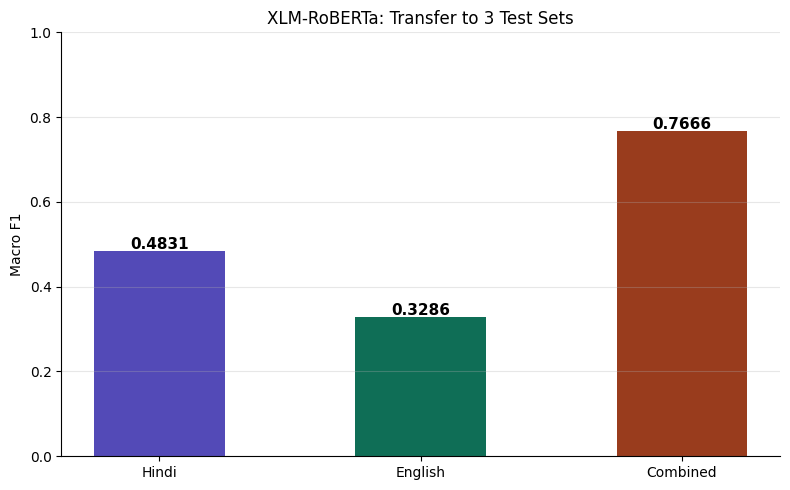

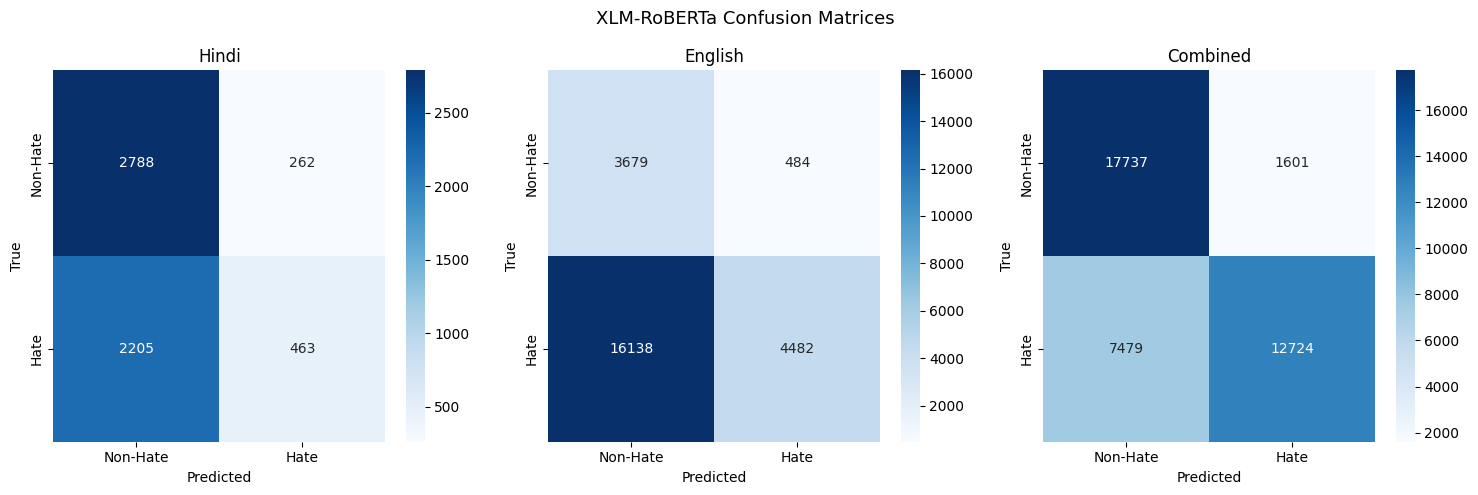

In [34]:
import seaborn as sns

rdf = pd.DataFrame([{k:v for k,v in r.items() if k not in ['preds','true']}
                     for r in all_results])
print("\n" + "="*60)
print(f"  XLM-RoBERTa — RESULTS TABLE")
print("="*60)
print(rdf[['dataset','macro_f1','weighted_f1','precision','recall']].to_string(index=False))
rdf.to_csv(f"{OUTPUT_DIR}/xlmr_results.csv", index=False)

# F1 bar chart
fig,ax = plt.subplots(figsize=(8,5))
colors = ['#534AB7','#0F6E56','#993C1D']
bars = ax.bar(rdf['dataset'], rdf['macro_f1'], color=colors, width=0.5)
for bar,v in zip(bars,rdf['macro_f1']):
    ax.text(bar.get_x()+bar.get_width()/2., bar.get_height()+.005,
            f'{v:.4f}', ha='center', fontweight='bold', fontsize=11)
ax.set_ylabel('Macro F1'); ax.set_title('XLM-RoBERTa: Transfer to 3 Test Sets')
ax.set_ylim(0,1.0); ax.grid(axis='y',alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.savefig(f"{OUTPUT_DIR}/xlmr_f1.png",dpi=150); plt.show()

# Confusion matrices
fig,axes = plt.subplots(1,3,figsize=(15,5))
for ax,r in zip(axes,all_results):
    cm=confusion_matrix(r['true'],r['preds'])
    sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',ax=ax,
                xticklabels=list(LABEL_MAP.values()),
                yticklabels=list(LABEL_MAP.values()))
    ax.set_title(r['dataset']); ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.suptitle('XLM-RoBERTa Confusion Matrices',fontsize=13)
plt.tight_layout(); plt.savefig(f"{OUTPUT_DIR}/xlmr_cm.png",dpi=150); plt.show()

## Step 9: XAI Analysis — LIME + AOPC

Run on all 3 test sets separately. Compare SHAP attributions on raw vs normalized input.

In [35]:
def pred_fn(texts):
    model.eval(); all_p=[]
    for i in range(0,len(texts),8):
        enc=tokenizer(list(texts[i:i+8]),return_tensors='pt',truncation=True,
                      padding=True,max_length=MAX_LEN).to(DEVICE)
        with torch.no_grad(): logits=model(**enc).logits
        all_p.extend(torch.softmax(logits,-1).cpu().numpy())
    return np.array(all_p)

def aopc(texts,n_steps=5):
    drops=[]
    for text in texts:
        tokens=text.split()
        if len(tokens)<3: continue
        orig=pred_fn([text])[0].max(); step=max(1,len(tokens)//n_steps)
        cum=0.0; rem=tokens.copy()
        for _ in range(n_steps):
            if not rem: break
            rem=rem[:-step]
            cum+=float(orig-pred_fn([' '.join(rem) if rem else '[MASK]'])[0].max())
        drops.append(cum/n_steps)
    return float(np.mean(drops)) if drops else 0.0

# XAI on all 3 test sets
xai_summary = []
for df_t, name in [(df_hindi,'Hindi'),(df_english,'English'),(df_combined,'Combined')]:
    texts     = df_t['text'].head(20).tolist()
    norm_texts= normalizer.normalize_batch(texts)
    ar, an    = aopc(texts), aopc(norm_texts)
    xai_summary.append({'dataset':name,'aopc_raw':ar,'aopc_norm':an,'delta':an-ar})
    print(f"  [{name}] AOPC Raw:{ar:.4f} | AOPC Norm:{an:.4f} | Δ={an-ar:+.4f}")

xai_df = pd.DataFrame(xai_summary)
xai_df.to_csv(f"{OUTPUT_DIR}/xlmr_xai.csv", index=False)
print("\nXAI summary saved")

  [Hindi] AOPC Raw:-0.0340 | AOPC Norm:-0.0065 | Δ=+0.0275
  [English] AOPC Raw:0.0090 | AOPC Norm:-0.0035 | Δ=-0.0125
  [Combined] AOPC Raw:-0.0081 | AOPC Norm:-0.0015 | Δ=+0.0066

XAI summary saved


In [37]:
!zip -r xlmr_results.zip /content/xlmr_results

  adding: content/xlmr_results/ (stored 0%)
  adding: content/xlmr_results/xlmr_results.csv (deflated 25%)
  adding: content/xlmr_results/best_model/ (stored 0%)
  adding: content/xlmr_results/best_model/training_args.bin (deflated 53%)
  adding: content/xlmr_results/best_model/model.safetensors (deflated 23%)
  adding: content/xlmr_results/best_model/tokenizer_config.json (deflated 47%)
  adding: content/xlmr_results/best_model/config.json (deflated 51%)
  adding: content/xlmr_results/best_model/tokenizer.json (deflated 77%)
  adding: content/xlmr_results/xlmr_xai.csv (deflated 32%)
  adding: content/xlmr_results/checkpoints/ (stored 0%)
  adding: content/xlmr_results/checkpoints/checkpoint-15695/ (stored 0%)
  adding: content/xlmr_results/checkpoints/checkpoint-15695/rng_state.pth (deflated 26%)
  adding: content/xlmr_results/checkpoints/checkpoint-15695/training_args.bin (deflated 53%)
  adding: content/xlmr_results/checkpoints/checkpoint-15695/scheduler.pt (deflated 61%)
  adding: 

In [38]:
from google.colab import files
files.download('xlmr_results.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [39]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 12.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=99b163b3c83080e95399f780c0467ede810ce9201f1626a6a27dbcea93766a08
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [40]:
# LIME comparison on hate speech examples
try:
    from lime.lime_text import LimeTextExplainer
    lime_exp = LimeTextExplainer(class_names=list(LABEL_MAP.values()))

    for df_t, name in [(df_hindi,'Hindi'),(df_english,'English'),(df_combined,'Combined')]:
        hate_samples = df_t[df_t['label']==1]['text'].head(2).tolist()
        print(f"\n{'='*55} LIME: {name} {'='*55}")
        for raw in hate_samples:
            norm = normalizer.normalize(raw)
            r_exp = lime_exp.explain_instance(raw,  pred_fn, num_features=6, num_samples=150)
            n_exp = lime_exp.explain_instance(norm, pred_fn, num_features=6, num_samples=150)
            print(f"  RAW : {raw[:60]}")
            print(f"  NORM: {norm[:60]}")
            rt = sorted(r_exp.as_list(), key=lambda x:abs(x[1]), reverse=True)[:3]
            nt = sorted(n_exp.as_list(), key=lambda x:abs(x[1]), reverse=True)[:3]
            print(f"  Top RAW  tokens: {[(f,round(w,3)) for f,w in rt]}")
            print(f"  Top NORM tokens: {[(f,round(w,3)) for f,w in nt]}\n")
except ImportError:
    print("Run: !pip install lime")


======================================================= LIME: Hindi =======================================================
  RAW : मेरे देश के हिन्दु बहुत निराले है। कुछ तो पक्के राम भक्त है 
  NORM: म र द श क ह न द बह त न र ल ह क छ त पक क र म भक त ह और क छ ब 
  Top RAW  tokens: [(np.str_('क'), 0.047), (np.str_('बर'), -0.043), (np.str_('म'), -0.031)]
  Top NORM tokens: [(np.str_('ह'), 0.048), (np.str_('र'), -0.046), (np.str_('जय'), -0.032)]

  RAW : @prabhav218 साले जेएनयू छाप कमिने लोग हिन्दुओं को यह कहते है
  NORM: [USER] स ल ज एनय छ प कम न ल ग ह न द ओ क यह कहत ह क स व ध न स
  Top RAW  tokens: [(np.str_('prabhav218'), -0.073), (np.str_('ल'), -0.051), (np.str_('अध'), 0.046)]
  Top NORM tokens: [(np.str_('USER'), -0.087), (np.str_('बर'), -0.086), (np.str_('यह'), 0.082)]


======================================================= LIME: English =======================================================
  RAW : !!!!! RT @mleew17: boy dats cold...tyga dwn bad for cuffin d
  NORM: rt [USER] bo

## Step 10: AOPC Comparison Chart Across All 3 Test Sets

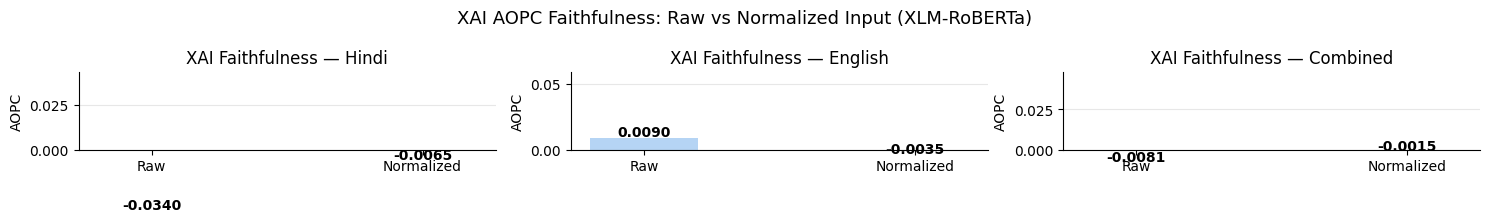

Saved all XAI plots


In [41]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, row in zip(axes, xai_summary):
    ar, an = row['aopc_raw'], row['aopc_norm']
    bars = ax.bar(['Raw','Normalized'],[ar,an],color=['#B5D4F4','#185FA5'],width=0.4)
    for bar,v in zip(bars,[ar,an]):
        ax.text(bar.get_x()+bar.get_width()/2.,bar.get_height()+.001,
                f'{v:.4f}',ha='center',fontweight='bold',fontsize=10)
    ax.set_title(f"XAI Faithfulness — {row['dataset']}"); ax.set_ylabel('AOPC')
    ax.set_ylim(0,max(ar,an)+0.05); ax.grid(axis='y',alpha=0.3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.suptitle('XAI AOPC Faithfulness: Raw vs Normalized Input (XLM-RoBERTa)',fontsize=13)
plt.tight_layout(); plt.savefig(f"{OUTPUT_DIR}/xlmr_aopc_all.png",dpi=150); plt.show()
print("Saved all XAI plots")

## Final Summary

In [42]:
print("="*65)
print("  XLM-RoBERTa COMPLETE RESULTS SUMMARY")
print("="*65)
print("\nTable 1 — Classification Performance:")
print(rdf[['dataset','macro_f1','weighted_f1','precision','recall']].to_string(index=False))
print("\nTable 2 — XAI Faithfulness (AOPC):")
print(xai_df[['dataset','aopc_raw','aopc_norm','delta']].to_string(index=False))
print("="*65)

  XLM-RoBERTa COMPLETE RESULTS SUMMARY

Table 1 — Classification Performance:
 dataset  macro_f1  weighted_f1  precision  recall
   Hindi    0.4831       0.4971     0.5985  0.5438
 English    0.3286       0.3430     0.5441  0.5505
Combined    0.7666       0.7660     0.7958  0.7735

Table 2 — XAI Faithfulness (AOPC):
 dataset  aopc_raw  aopc_norm     delta
   Hindi -0.033987  -0.006490  0.027497
 English  0.009010  -0.003463 -0.012473
Combined -0.008131  -0.001492  0.006640
